# Disaster Tweets: EDA and 1.5B Baseline

Kaggle **Natural Language Processing with Disaster Tweets** (`nlp-getting-started`).

Goal: classify a tweet as a **real disaster** (`1`) or **not** (`0`). The competition metric is **F1**.

**Baseline model:** [`Qwen/Qwen2.5-1.5B-Instruct`](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct) (1.5B, Apache-2.0) fine-tuned with LoRA for sequence classification on Apple MPS.

A TF-IDF + logistic regression model is trained first as a classical reference.

In [1]:
from pathlib import Path
import json, os, re, warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 12

ROOT = Path.cwd()
if not (ROOT / "data" / "train.csv").exists():
    ROOT = Path("/Users/nine/Desktop/CMKL/3.1/sys304/milestone/1")
DATA = ROOT / "data"
MODELS = ROOT / "models"
MODELS.mkdir(exist_ok=True)
print("data:", DATA)

data: /Users/nine/Desktop/CMKL/3.1/sys304/milestone/1/data


## 1. Load and overview

In [2]:
train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")

train["keyword"] = train["keyword"].fillna("").str.replace("%20", " ", regex=False)
test["keyword"] = test["keyword"].fillna("").str.replace("%20", " ", regex=False)
train["location"] = train["location"].fillna("")
test["location"] = test["location"].fillna("")

print(f"train: {train.shape[0]:,} rows × {train.shape[1]} cols")
print(f"test:  {test.shape[0]:,} rows × {test.shape[1]} cols")
print("train columns:", list(train.columns))
print("test columns:", list(test.columns))
train.head()

train: 7,613 rows × 5 cols
test:  3,263 rows × 4 cols
train columns: ['id', 'keyword', 'location', 'text', 'target']
test columns: ['id', 'keyword', 'location', 'text']


,id,keyword,location,text,target
0,1,,,Our Deeds are the Reason of this #earthquake M...,1
1,4,,,Forest fire near La Ronge Sask. Canada,1
2,5,,,All residents asked to 'shelter in place' are ...,1
3,6,,,"13,000 people receive #wildfires evacuation or...",1
4,7,,,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
overview = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "nunique": train.nunique(dropna=False),
    "empty_string": (train == "").sum(),
    "nulls": train.isna().sum(),
})
overview

,dtype,nunique,empty_string,nulls
id,int64,7613,0,0
keyword,str,222,61,0
location,str,3342,2533,0
text,str,7503,0,0
target,int64,2,0,0


## 2. Target balance

Slightly imbalanced: more non-disaster tweets. F1 on the positive class (and macro/weighted F1) matters more than raw accuracy.

target
not disaster (0)    4342
disaster (1)        3271
Name: count, dtype: int64
disaster rate: 43.0%


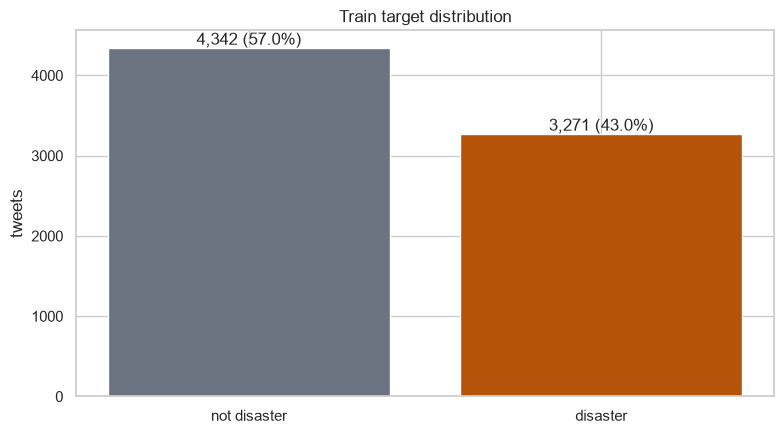

In [4]:
vc = train["target"].value_counts().sort_index()
print(vc.rename({0: "not disaster (0)", 1: "disaster (1)"}))
print(f"disaster rate: {train['target'].mean():.1%}")

fig, ax = plt.subplots()
ax.bar(["not disaster", "disaster"], vc.values, color=["#6b7280", "#b45309"])
ax.set_ylabel("tweets")
ax.set_title("Train target distribution")
for i, n in enumerate(vc.values):
    ax.text(i, n + 40, f"{n:,} ({n/len(train):.1%})", ha="center")
plt.tight_layout()
plt.show()

## 3. Missing fields and text length

In [5]:
print("empty keyword:", (train["keyword"] == "").sum(), f"({(train['keyword']=='').mean():.1%})")
print("empty location:", (train["location"] == "").sum(), f"({(train['location']=='').mean():.1%})")
print("test empty keyword:", (test["keyword"] == "").sum())
print("test empty location:", (test["location"] == "").sum())

train["n_chars"] = train["text"].str.len()
train["n_words"] = train["text"].str.split().str.len()
print(train[["n_chars", "n_words"]].describe().round(1))

empty keyword: 61 (0.8%)
empty location: 2533 (33.3%)
test empty keyword: 26
test empty location: 1105
       n_chars  n_words
count   7613.0   7613.0
mean     101.0     14.9
std       33.8      5.7
min        7.0      1.0
25%       78.0     11.0
50%      107.0     15.0
75%      133.0     19.0
max      157.0     31.0


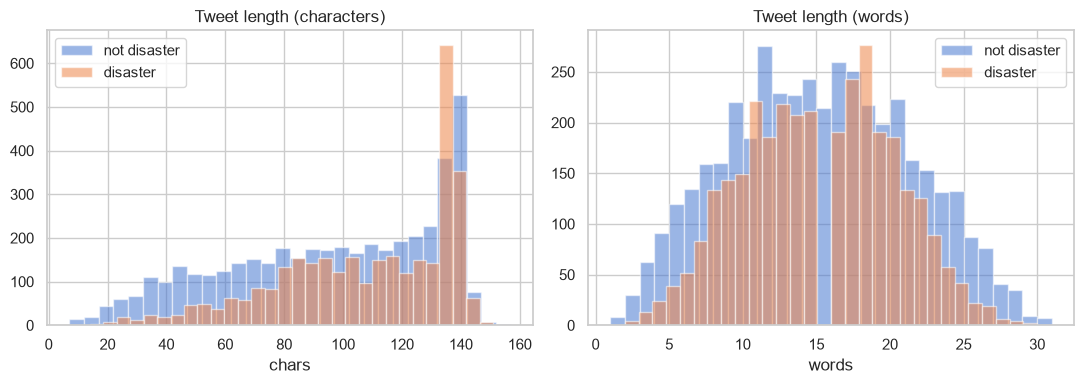

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in [
    (axes[0], "n_chars", "Tweet length (characters)"),
    (axes[1], "n_words", "Tweet length (words)"),
]:
    for label, name in [(0, "not disaster"), (1, "disaster")]:
        ax.hist(train.loc[train["target"] == label, col], bins=30, alpha=0.55, label=name)
    ax.set_title(title)
    ax.set_xlabel(col.replace("n_", ""))
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Keywords

Keywords are a strong prior: `wreckage` / `derailment` / `debris` are almost always disasters; `aftershock` / `body bags` / `blazing` are almost never. The model should see the keyword, not only the tweet body.

In [7]:
kw = (
    train[train["keyword"] != ""]
    .groupby("keyword")["target"]
    .agg(disaster_rate="mean", n="count")
    .query("n >= 20")
    .sort_values("disaster_rate")
)
print("unique keywords:", train["keyword"].nunique())
print("\nMost disaster-like:")
display(kw.tail(12).iloc[::-1])
print("Least disaster-like:")
display(kw.head(12))

unique keywords: 222

Most disaster-like:


,disaster_rate,n
keyword,,
debris,1.000000,37
wreckage,1.000000,39
derailment,1.000000,39
outbreak,0.975000,40
typhoon,0.973684,38
oil spill,0.973684,38
suicide bombing,0.969697,33
suicide bomber,0.967742,31
bombing,0.931034,29


Least disaster-like:


,disaster_rate,n
keyword,,
aftershock,0.000000,34
body bags,0.024390,41
ruin,0.027027,37
blazing,0.029412,34
body bag,0.030303,33
electrocute,0.031250,32
screaming,0.055556,36
traumatised,0.057143,35
panicking,0.060606,33


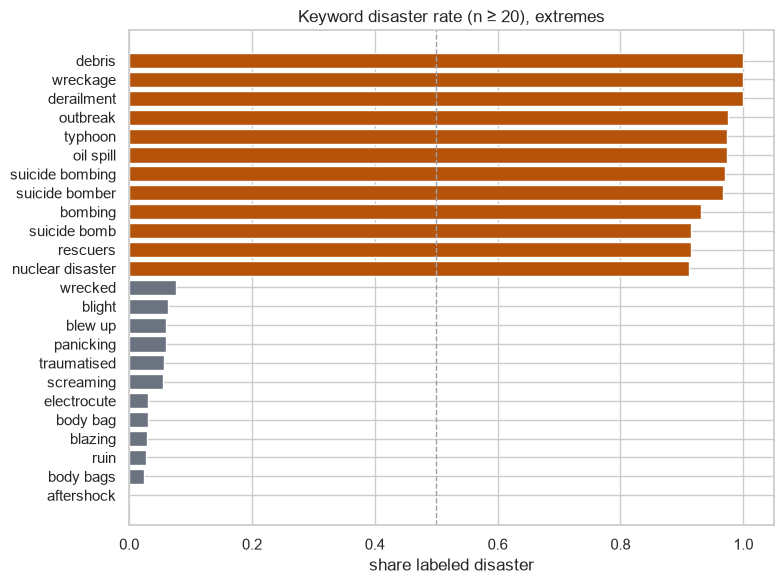

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_kw = pd.concat([kw.head(12), kw.tail(12)])
colors = ["#6b7280" if r < 0.5 else "#b45309" for r in plot_kw["disaster_rate"]]
ax.barh(plot_kw.index, plot_kw["disaster_rate"], color=colors)
ax.axvline(0.5, color="#9ca3af", ls="--", lw=1)
ax.set_xlabel("share labeled disaster")
ax.set_title("Keyword disaster rate (n ≥ 20), extremes")
plt.tight_layout()
plt.show()

## 5. Locations, URLs, and duplicates

In [9]:
print("unique locations:", train["location"].nunique())
print(train[train["location"] != ""]["location"].value_counts().head(10))

train["has_url"] = train["text"].str.contains(r"https?://", regex=True)
train["has_mention"] = train["text"].str.contains(r"@\w", regex=True)
train["has_hashtag"] = train["text"].str.contains(r"#\w", regex=True)
feat = train.groupby("target")[["has_url", "has_mention", "has_hashtag"]].mean()
feat.index = ["not disaster", "disaster"]
print("\nfeature rates by class:")
display(feat.round(3))

dup = train["text"].duplicated(keep=False)
conflict = (
    train.groupby("text")["target"].nunique().gt(1).sum()
)
print(f"duplicate tweets: {train['text'].duplicated().sum()} extra copies")
print(f"texts with conflicting labels: {conflict}")

unique locations: 3342
location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Name: count, dtype: int64

feature rates by class:


,has_url,has_mention,has_hashtag
not disaster,0.414,0.309,0.204
disaster,0.664,0.204,0.262


duplicate tweets: 110 extra copies
texts with conflicting labels: 18


In [10]:
print("Disaster examples")
display(train.loc[train["target"] == 1, ["keyword", "location", "text"]].head(4))
print("Non-disaster examples")
display(train.loc[train["target"] == 0, ["keyword", "location", "text"]].head(4))

Disaster examples


,keyword,location,text
0,,,Our Deeds are the Reason of this #earthquake M...
1,,,Forest fire near La Ronge Sask. Canada
2,,,All residents asked to 'shelter in place' are ...
3,,,"13,000 people receive #wildfires evacuation or..."


Non-disaster examples


,keyword,location,text
15,,,What's up man?
16,,,I love fruits
17,,,Summer is lovely
18,,,My car is so fast


## 6. Classical baseline: TF-IDF + logistic regression

Fast, strong bag-of-words reference. Input is `keyword` plus tweet text. Stratified 80/20 split; metric is F1 (positive class and weighted).

              precision    recall  f1-score   support

not disaster       0.83      0.83      0.83       869
    disaster       0.78      0.78      0.78       654

    accuracy                           0.81      1523
   macro avg       0.81      0.80      0.81      1523
weighted avg       0.81      0.81      0.81      1523

F1 (disaster class): 0.7774
F1 (weighted):      0.8089


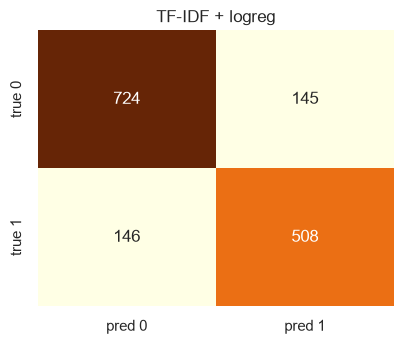

saved

 /Users/nine/Desktop/CMKL/3.1/sys304/milestone/1/models/tfidf_logreg.joblib


In [11]:
def build_input(df: pd.DataFrame) -> pd.Series:
    kw = df["keyword"].fillna("").str.strip()
    return np.where(kw.eq(""), df["text"], "keyword: " + kw + "\n" + df["text"])

X = build_input(train)
y = train["target"].astype(int).to_numpy()

X_tr, X_va, y_tr, y_va, idx_tr, idx_va = train_test_split(
    X, y, train.index, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(min_df=2, ngram_range=(1, 2), max_features=50_000)
lr = LogisticRegression(max_iter=1000, class_weight="balanced", C=2.0)
lr.fit(tfidf.fit_transform(X_tr), y_tr)
pred_lr = lr.predict(tfidf.transform(X_va))

print(classification_report(y_va, pred_lr, target_names=["not disaster", "disaster"]))
print("F1 (disaster class):", round(f1_score(y_va, pred_lr), 4))
print("F1 (weighted):     ", round(f1_score(y_va, pred_lr, average="weighted"), 4))

cm = confusion_matrix(y_va, pred_lr)
fig, ax = plt.subplots(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr", cbar=False, ax=ax,
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
ax.set_title("TF-IDF + logreg")
plt.tight_layout()
plt.show()

import joblib
joblib.dump({"vectorizer": tfidf, "model": lr}, MODELS / "tfidf_logreg.joblib")
print("saved", MODELS / "tfidf_logreg.joblib")

## 7. Open-source 1.5B baseline: Qwen2.5-1.5B-Instruct + LoRA

Why this model:
- **1.5B params** — in the requested 1–2B range, fits in 24 GB unified memory with LoRA.
- **Apache-2.0**, no gated Hugging Face access.
- Instruct checkpoint follows short classification prompts well.

We attach a 2-class head (`AutoModelForSequenceClassification`) and train LoRA adapters on the split from section 6. The adapter (not the full 3 GB base) is what we save.

In [12]:
import torch
from datasets import Dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
SAVE_DIR = MODELS / "qwen2.5-1.5b-disaster-lora"
MAX_LEN = 128
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)
print("model:", MODEL_ID)

device: mps
model: Qwen/Qwen2.5-1.5B-Instruct


In [13]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

def to_hf(texts, labels):
    ds = Dataset.from_dict({"text": list(texts), "label": list(map(int, labels))})
    def tok(batch):
        return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)
    return ds.map(tok, batched=True, remove_columns=["text"])

ds_tr = to_hf(X_tr, y_tr)
ds_va = to_hf(X_va, y_va)
collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(ds_tr)
print("example ids len", len(ds_tr[0]["input_ids"]))

Map:   0%|          | 0/6090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1523 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 6090
})
example ids len 42


In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1": f1_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "accuracy": (preds == labels).mean(),
    }

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=2,
    dtype=torch.float32,
)
model.config.pad_token_id = tokenizer.pad_token_id
model.config.problem_type = "single_label_classification"

model = get_peft_model(
    model,
    LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        bias="none",
        modules_to_save=["score"],
    ),
)
model.print_trainable_parameters()
model.to(device)

args = TrainingArguments(
    output_dir=str(MODELS / "qwen-runs"),
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=0.06,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    seed=42,
    bf16=False,
    fp16=False,
    dataloader_num_workers=0,
    remove_unused_columns=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_tr,
    eval_dataset=ds_va,
    data_collator=collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

train_result = trainer.train()
metrics = trainer.evaluate()
print(train_result.metrics)
print(metrics)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 4,361,216 || all params: 1,548,078,592 || trainable%: 0.2817


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1,F1 Weighted,Accuracy
1,2.554181,0.361698,0.816260,0.850090,0.851609


Training Loss,Validation Loss,Epoch,F1,F1 Weighted,Accuracy
2.554181,0.361698,1,0.816260,0.850090,0.851609


{'train_runtime': 796.9635, 'train_samples_per_second': 7.642, 'train_steps_per_second': 0.478, 'total_flos': 1975512388466688.0, 'train_loss': 4.014792887870408, 'epoch': 1.0}
{'eval_loss': 0.36169832944869995, 'eval_f1': 0.816260162601626, 'eval_f1_weighted': 0.8500903943339057, 'eval_accuracy': 0.8516086671043992}


              precision    recall  f1-score   support

not disaster       0.84      0.91      0.88       869
    disaster       0.87      0.77      0.82       654

    accuracy                           0.85      1523
   macro avg       0.86      0.84      0.85      1523
weighted avg       0.85      0.85      0.85      1523

F1 (disaster class): 0.8163


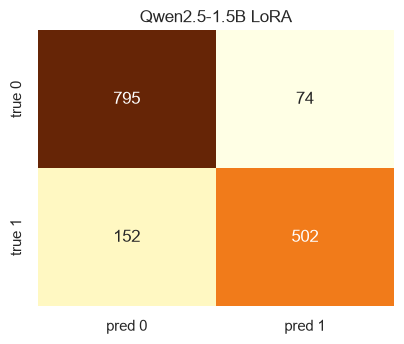

In [15]:
pred_out = trainer.predict(ds_va)
pred_llm = np.argmax(pred_out.predictions, axis=-1)
print(classification_report(y_va, pred_llm, target_names=["not disaster", "disaster"]))
print("F1 (disaster class):", round(f1_score(y_va, pred_llm), 4))

cm = confusion_matrix(y_va, pred_llm)
fig, ax = plt.subplots(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr", cbar=False, ax=ax,
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
ax.set_title("Qwen2.5-1.5B LoRA")
plt.tight_layout()
plt.show()

## 8. Save adapters and write a test submission

In [16]:
SAVE_DIR.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(SAVE_DIR))
tokenizer.save_pretrained(str(SAVE_DIR))
(SAVE_DIR / "metrics.json").write_text(json.dumps({
    "model_id": MODEL_ID,
    "val_f1_disaster": float(f1_score(y_va, pred_llm)),
    "val_f1_weighted": float(f1_score(y_va, pred_llm, average="weighted")),
    "tfidf_f1_disaster": float(f1_score(y_va, pred_lr)),
    "n_train": int(len(X_tr)),
    "n_val": int(len(X_va)),
}, indent=2))
print("saved LoRA adapter to", SAVE_DIR)

test_texts = build_input(test)
ds_te = to_hf(test_texts, np.zeros(len(test), dtype=int))
te_pred = np.argmax(trainer.predict(ds_te).predictions, axis=-1)
sub = pd.DataFrame({"id": test["id"], "target": te_pred.astype(int)})
sub_path = DATA / "submission.csv"
sub.to_csv(sub_path, index=False)
print("wrote", sub_path, "shape", sub.shape)
sub.head()

saved LoRA adapter to /Users/nine/Desktop/CMKL/3.1/sys304/milestone/1/models/qwen2.5-1.5b-disaster-lora


Map:   0%|          | 0/3263 [00:00<?, ? examples/s]

wrote /Users/nine/Desktop/CMKL/3.1/sys304/milestone/1/data/submission.csv shape (3263, 2)


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


## Reload the saved LoRA adapter

```python
from peft import AutoPeftModelForSequenceClassification
from transformers import AutoTokenizer

path = "models/qwen2.5-1.5b-disaster-lora"
tok = AutoTokenizer.from_pretrained(path)
model = AutoPeftModelForSequenceClassification.from_pretrained(path)
```

The 1.5B base weights stay in the Hugging Face cache; this folder is only the LoRA adapter (~17 MB), tokenizer, and `metrics.json`.
